In [2]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt

import json

In [3]:
PINNModel = nn.Sequential(
    nn.Linear(2, 64),
    nn.Tanh(),
    nn.Linear(64, 64),
    nn.Tanh(),
    nn.Linear(64, 64),
    nn.Tanh(),
    nn.Linear(64, 3)
).double()

PINNModel.load_state_dict(torch.load("../models/kova_ft_sans_cl/PINN_Model_09_ft.pt"))
PINNModel.eval()

Sequential(
  (0): Linear(in_features=2, out_features=64, bias=True)
  (1): Tanh()
  (2): Linear(in_features=64, out_features=64, bias=True)
  (3): Tanh()
  (4): Linear(in_features=64, out_features=64, bias=True)
  (5): Tanh()
  (6): Linear(in_features=64, out_features=3, bias=True)
)

In [4]:
Re = 60
nu = 1 / Re
l = 1 / (2 * nu) - np.sqrt(1 / (4 * nu ** 2) + 4 * np.pi ** 2)

def u_func(x, y):
    return 1 - np.exp(l * x) * np.cos(2 * np.pi * y)

def v_func(x, y):
    return (l / (2 * np.pi)) * np.exp(l * x) * np.sin(2 * np.pi * y)

def p_func(x):
    return 1 / 2 * (1 - np.exp(2 * l * x))


In [5]:
inside_points = np.column_stack((np.random.uniform(-0.5, 1.0, 2000), np.random.uniform(-0.5, 1.5, 2000)))
outside_points = np.array([[-0.5, i] for i in np.linspace(-0.5, 1.5, 50)] + [[1, i] for i in np.linspace(-0.5, 1.5, 50)] + [[i, -0.5] for i in np.linspace(-0.5, 1, 50)] + [[i, 1.5] for i in np.linspace(-0.5, 1, 50)])

In [6]:
inside_results = PINNModel(torch.Tensor(inside_points).double()).detach().numpy()
outside_results = PINNModel(torch.Tensor(outside_points).double()).detach().numpy()

In [7]:
inside_true_results = np.column_stack((u_func(inside_points[:, 0], inside_points[:, 1]) , v_func(inside_points[:, 0], inside_points[:, 1]), p_func(inside_points[:, 0])))
outside_true_results = np.column_stack((u_func(outside_points[:, 0], outside_points[:, 1]) , v_func(outside_points[:, 0], outside_points[:, 1]), p_func(outside_points[:, 0])))

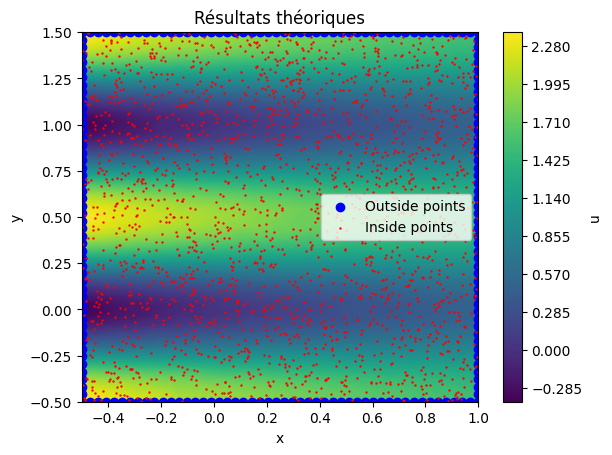

In [8]:
plt.tricontourf(np.concatenate((inside_points[:, 0], outside_points[:, 0])), np.concatenate((inside_points[:, 1], outside_points[:, 1])), np.concatenate((inside_true_results[:, 0], outside_true_results[:, 0])),levels=250, cmap='viridis')
plt.colorbar(label='u')

plt.scatter(outside_points[:, 0], outside_points[:, 1], c='b', label="Outside points")
plt.scatter(inside_points[:, 0], inside_points[:, 1], c='r', s=0.5, label="Inside points")
plt.legend()
plt.xlabel('x')
plt.ylabel('y')
plt.title('Résultats théoriques')
plt.show()

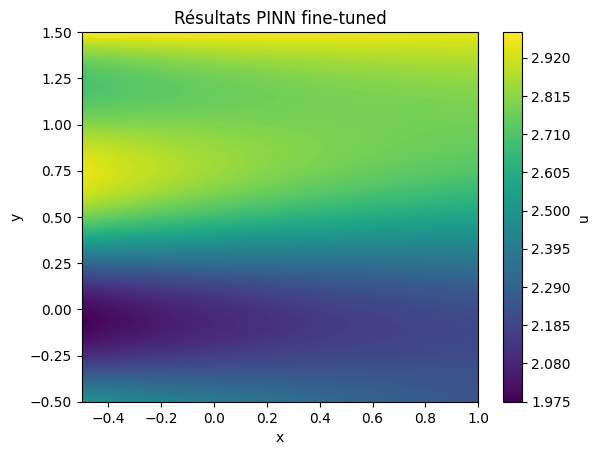

In [9]:
plt.tricontourf(np.concatenate((inside_points[:, 0], outside_points[:, 0])), np.concatenate((inside_points[:, 1], outside_points[:, 1])), np.concatenate((inside_results[:, 0], outside_results[:, 0])),levels=250, cmap='viridis')
plt.colorbar(label='u')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Résultats PINN fine-tuned')
plt.show()

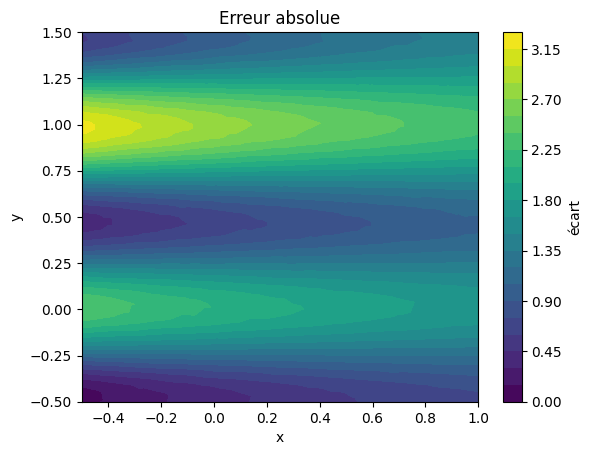

In [10]:
plt.tricontourf(
    np.concatenate((inside_points[:, 0], outside_points[:, 0])),
    np.concatenate((inside_points[:, 1], outside_points[:, 1])),
    np.concatenate((
        np.abs(inside_results[:, 0] - inside_true_results[:, 0]),
        np.abs(outside_results[:, 0] - outside_true_results[:, 0]))
    ),
    levels=20,
    cmap='viridis'
)
plt.colorbar(label='écart')

plt.xlabel('x')
plt.ylabel('y')
plt.title('Erreur absolue')
plt.show()

In [15]:
losses = []

with open("../models/kova_ft/losses_Model_04_ft.json", "r") as f:
    losses = [i for i in json.load(f) if isinstance(i, list)]

losses = np.array(losses)
print(losses)

[[4.37570602e-02 1.06988301e-03 2.19743411e-06 1.88888471e-02]
 [6.67709866e-03 3.00656270e-04 8.38207765e-03 3.22579516e-02]
 [7.33671148e-03 3.78896241e-04 2.36010193e-03 2.45450438e-02]
 ...
 [9.50282737e-07 5.63270150e-07 5.52868697e-07 3.06846758e-07]
 [9.50282737e-07 5.63270150e-07 5.52868697e-07 3.06846758e-07]
 [9.50282737e-07 5.63270150e-07 5.52868697e-07 3.06846758e-07]]


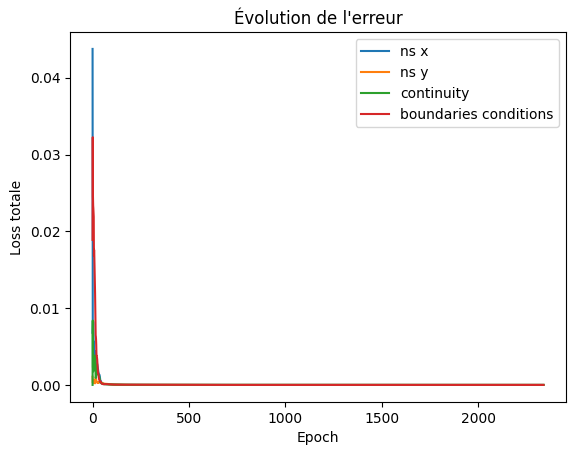

In [12]:
labels = ["ns x", "ns y", "continuity", "boundaries conditions", "total"]

lines = plt.plot(losses)

for line, label in zip(lines, labels):
    line.set_label(label)

plt.xlabel('Epoch')
plt.ylabel('Loss totale')
plt.title('Évolution de l\'erreur')
plt.legend()
plt.show()

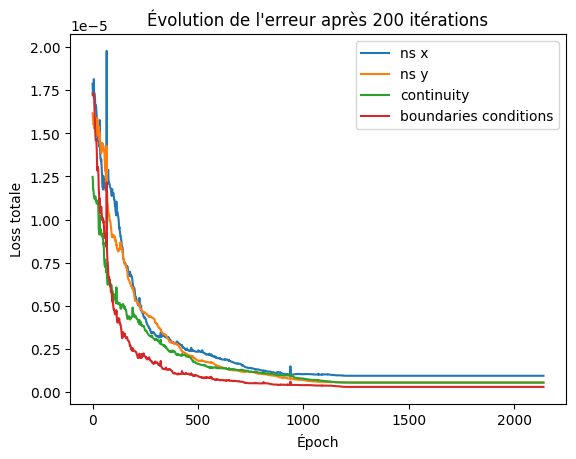

In [13]:
labels = ["ns x", "ns y", "continuity", "boundaries conditions", "total"]

lines = plt.plot(losses[200:])

for line, label in zip(lines, labels):
    line.set_label(label)

plt.xlabel('Époch')
plt.ylabel('Loss totale')
plt.title('Évolution de l\'erreur après 200 itérations')
plt.legend()
plt.show()

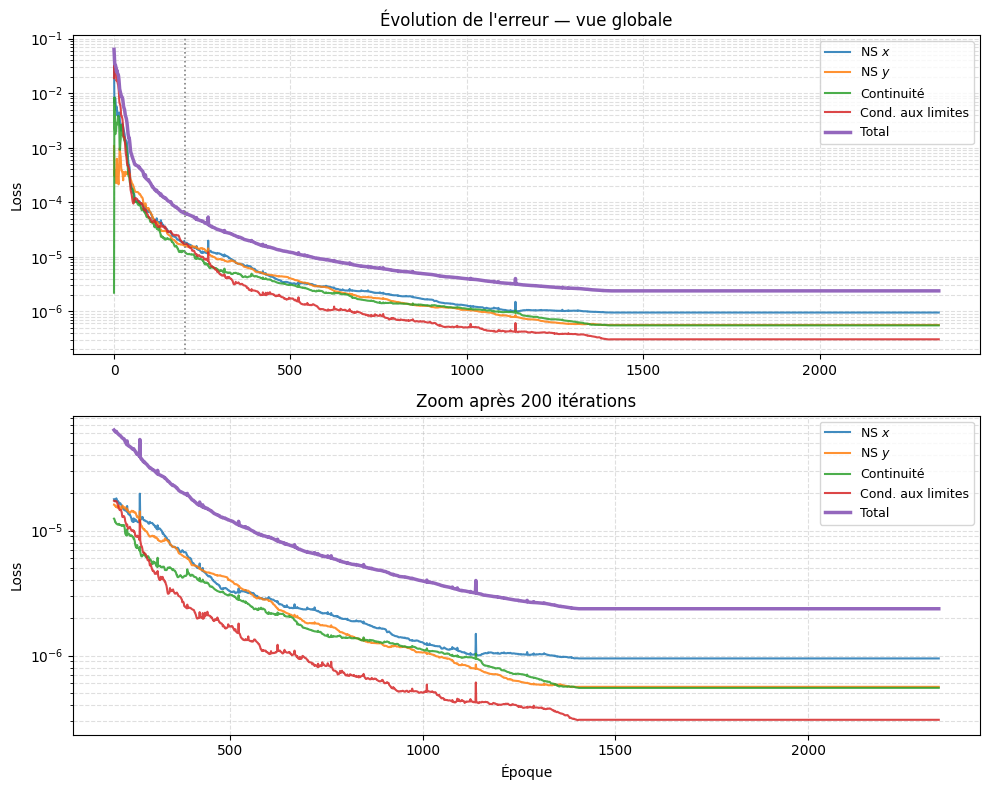

In [19]:
import numpy as np
import matplotlib.pyplot as plt

losses_arr = np.array(losses)  # shape (N, 4)
losses_total = np.hstack([losses_arr, losses_arr.sum(axis=1, keepdims=True)])  # shape (N, 5)

labels = ["NS $x$", "NS $y$", "Continuité", "Cond. aux limites", "Total"]
colors = plt.rcParams['axes.prop_cycle'].by_key()['color'][:len(labels)]

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8), sharex=False)

# ── Graphique 1 : toutes les époques ────────────────────────────
for i, (col, label) in enumerate(zip(colors, labels)):
    ax1.plot(losses_total[:, i], color=col, label=label,
             linewidth=1.5 if label != "Total" else 2.5,
             alpha=0.85 if label != "Total" else 1.0)

ax1.set_ylabel("Loss")
ax1.set_title("Évolution de l'erreur — vue globale")
ax1.legend(loc="upper right", fontsize=9)
ax1.set_yscale("log")
ax1.grid(True, which="both", linestyle="--", alpha=0.4)
ax1.axvline(x=200, color="gray", linestyle=":", linewidth=1.2)

# ── Graphique 2 : après 200 époques ─────────────────────────────
for i, (col, label) in enumerate(zip(colors, labels)):
    ax2.plot(range(200, len(losses_total)), losses_total[200:, i], color=col, label=label,
             linewidth=1.5 if label != "Total" else 2.5,
             alpha=0.85 if label != "Total" else 1.0)

ax2.set_xlabel("Époque")
ax2.set_ylabel("Loss")
ax2.set_title("Zoom après 200 itérations")
ax2.legend(loc="upper right", fontsize=9)
ax2.set_yscale("log")
ax2.grid(True, which="both", linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()